In [1]:
# Define the verbose variable
verbose = False

# Check if we're running in a Jupyter Notebook (not compiled script)
try:
    __IPYTHON__
    verbose = True  # Set verbose to True if running in a Jupyter Notebook
except NameError:
    pass  # Do nothing if we're not in a notebook

In [2]:
# All the imports

import torch
from torch.utils.data import TensorDataset
from torch import nn
import matplotlib.pyplot as plt

from load_dataset import labelList, get_data
from preprocess import preprocess_dataset
import bigmodel

from ml_util.eeg_util import plotEEG, plotTimeFreqEEG
from ml_util.checkpoint import checkpoint
from ml_util.data_module import DataModule
from ml_util.trainer import GoodClassificationModel, GoodTrainer
from ml_util.logger import WandBReporter, print_stats


torch.manual_seed(42)

In [3]:
print("Loading raw dataset")
X_raw, y = checkpoint(lambda: get_data(verbose=True), "raw_input")

Loading raw dataset


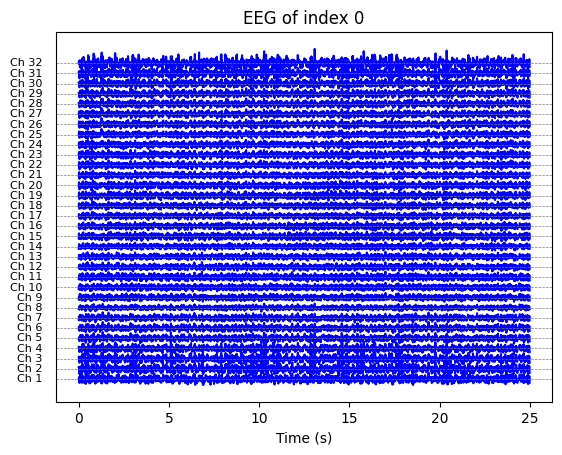

Arithmetic


In [4]:
if verbose:
    plotEEG(X_raw[0], title="index 0")
    print(labelList[y[0]])

In [5]:
# Applies preprocessing
print("Preprocessing input data")
X = checkpoint(lambda : preprocess_dataset(X_raw, verbose=True), "preprocessed")
print(f"Input dataset shape: {X.shape}")

# Stores in a TensorDataset
dataset = DataModule(X, y)

# Uncomment to try overfitting
# dataset = dataset.get_part(0.25)

Preprocessing input data
Input dataset shape: torch.Size([480, 32, 5, 51])


<Figure size 640x480 with 0 Axes>

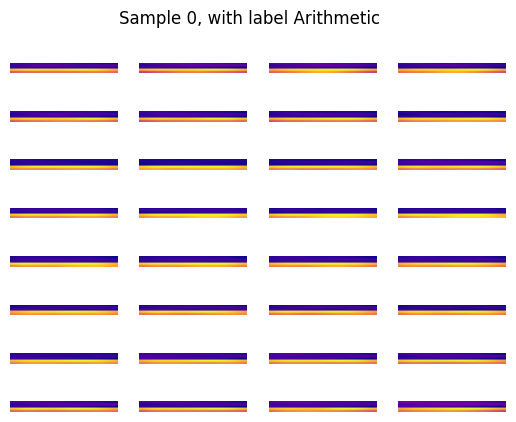

<Figure size 640x480 with 0 Axes>

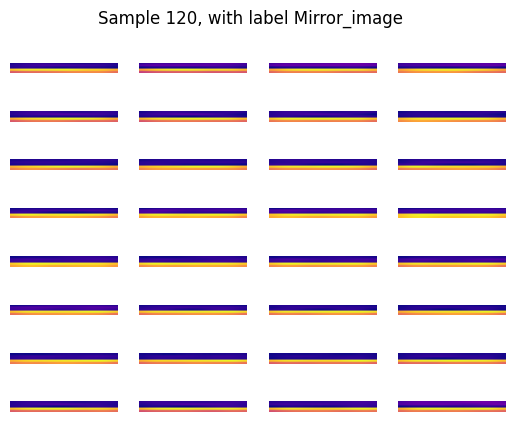

<Figure size 640x480 with 0 Axes>

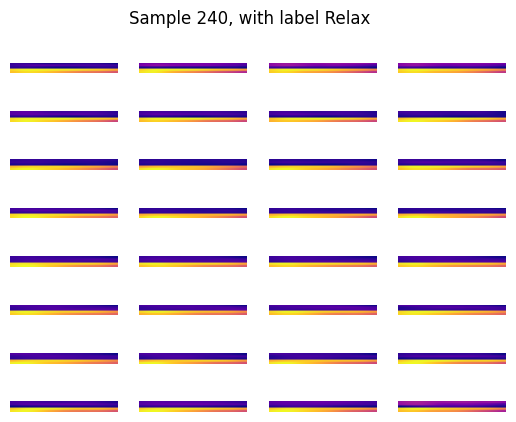

<Figure size 640x480 with 0 Axes>

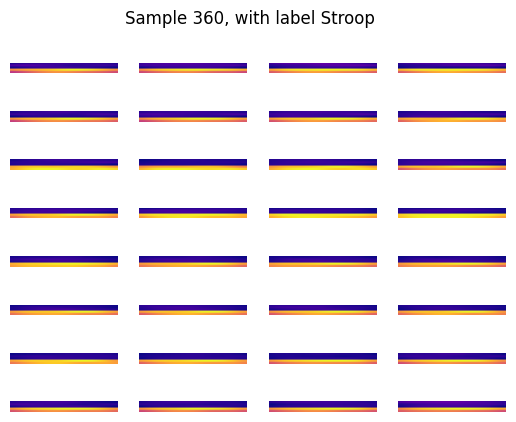

In [6]:
if verbose:
    for label in range(4):
        sampleId = torch.where(y==label)[0][0]
        plt.figure()
        fig, axes = plotTimeFreqEEG(X[sampleId])
        #plt.imshow(X[sampleId][0])
        fig.suptitle(f"Sample {sampleId}, with label {labelList[y[sampleId]]}")
    plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU" if torch.cuda.is_available() else "CPU")

hyperparams = {
    'lr': 1e-3,
    'weight_decay': 3e-2,
    'batch_size': 16
}
model = bigmodel.model(X[0])
loss_fn = nn.CrossEntropyLoss()

classification_model = GoodClassificationModel(model, loss_fn, hyperparams, device, 4)
trainer = GoodTrainer()

def babysitter(goodModel):
    if (goodModel.epoch %  10 == 0):
        goodModel.hyperparameters['lr'] = 0.8 * goodModel.hyperparameters['lr']

trainer.add_babysitter(babysitter)
trainer.add_logger(print_stats)
trainer.add_logger(WandBReporter(hyperparams, labelList))

CPU


wandb: Currently logged in as: ulyssedurand (ulyssedurand-ens-de-lyon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
trainer.train(classification_model, dataset, 1000)

Epoch:    1    | tl: 30.501551, ta: 0.232143    |    vl: 7.145074, va: 0.194444
Epoch:    2    | tl: 29.627075, ta: 0.273810    |    vl: 7.176013, va: 0.180556
Epoch:    3    | tl: 29.481955, ta: 0.267857    |    vl: 7.157527, va: 0.208333
Epoch:    4    | tl: 29.365839, ta: 0.297619    |    vl: 7.181041, va: 0.194444
Epoch:    5    | tl: 29.436121, ta: 0.261905    |    vl: 7.037807, va: 0.208333
Epoch:    6    | tl: 28.961460, ta: 0.291667    |    vl: 7.075123, va: 0.236111
Epoch:    7    | tl: 29.016003, ta: 0.288690    |    vl: 7.157983, va: 0.208333
Epoch:    8    | tl: 29.069147, ta: 0.270833    |    vl: 7.329067, va: 0.208333
Epoch:    9    | tl: 28.563511, ta: 0.330357    |    vl: 7.050377, va: 0.222222
Epoch:   10    | tl: 29.103685, ta: 0.306548    |    vl: 7.309274, va: 0.194444
Epoch:   11    | tl: 28.346355, ta: 0.306548    |    vl: 7.515698, va: 0.208333
Epoch:   12    | tl: 28.401760, ta: 0.312500    |    vl: 7.297389, va: 0.236111
Epoch:   13    | tl: 28.598164, ta: 0.32

Epoch:  104    | tl: 17.425880, ta: 0.711310    |    vl: 5.837406, va: 0.541667
Epoch:  105    | tl: 17.050350, ta: 0.729167    |    vl: 5.467269, va: 0.555556
Epoch:  106    | tl: 17.739292, ta: 0.690476    |    vl: 5.474737, va: 0.541667
Epoch:  107    | tl: 17.331427, ta: 0.702381    |    vl: 5.587861, va: 0.513889
Epoch:  108    | tl: 17.342314, ta: 0.726190    |    vl: 5.576570, va: 0.555556
Epoch:  109    | tl: 17.010012, ta: 0.708333    |    vl: 5.590428, va: 0.541667
Epoch:  110    | tl: 17.330620, ta: 0.720238    |    vl: 5.952026, va: 0.500000
Epoch:  111    | tl: 16.629944, ta: 0.732143    |    vl: 5.775982, va: 0.583333
Epoch:  112    | tl: 17.163046, ta: 0.735119    |    vl: 6.010349, va: 0.527778
Epoch:  113    | tl: 16.103083, ta: 0.776786    |    vl: 5.560160, va: 0.527778
Epoch:  114    | tl: 16.291416, ta: 0.726190    |    vl: 5.758345, va: 0.513889
Epoch:  115    | tl: 16.624376, ta: 0.758929    |    vl: 5.942179, va: 0.527778
Epoch:  116    | tl: 16.710051, ta: 0.73

Epoch:  207    | tl: 12.272855, ta: 0.851190    |    vl: 5.677261, va: 0.513889
Epoch:  208    | tl: 12.662959, ta: 0.830357    |    vl: 5.710087, va: 0.527778
Epoch:  209    | tl: 11.792904, ta: 0.863095    |    vl: 5.608662, va: 0.513889
Epoch:  210    | tl: 12.186120, ta: 0.863095    |    vl: 5.560292, va: 0.527778
Epoch:  211    | tl: 12.428528, ta: 0.857143    |    vl: 5.588311, va: 0.527778
Epoch:  212    | tl: 12.513605, ta: 0.851190    |    vl: 5.576679, va: 0.527778
Epoch:  213    | tl: 12.319013, ta: 0.863095    |    vl: 5.671147, va: 0.513889
Epoch:  214    | tl: 12.133574, ta: 0.860119    |    vl: 5.579992, va: 0.527778
Epoch:  215    | tl: 12.340657, ta: 0.872024    |    vl: 5.603379, va: 0.513889
Epoch:  216    | tl: 11.717755, ta: 0.866071    |    vl: 5.657789, va: 0.541667
Epoch:  217    | tl: 11.745046, ta: 0.877976    |    vl: 5.606261, va: 0.541667
Epoch:  218    | tl: 11.719826, ta: 0.877976    |    vl: 5.579501, va: 0.555556
Epoch:  219    | tl: 11.664692, ta: 0.88

Epoch:  310    | tl: 11.886023, ta: 0.854167    |    vl: 5.673550, va: 0.513889
Epoch:  311    | tl: 11.623408, ta: 0.872024    |    vl: 5.609960, va: 0.527778
Epoch:  312    | tl: 11.674136, ta: 0.883929    |    vl: 5.630355, va: 0.513889
Epoch:  313    | tl: 11.881323, ta: 0.842262    |    vl: 5.626073, va: 0.541667
Epoch:  314    | tl: 11.344204, ta: 0.880952    |    vl: 5.599417, va: 0.569444
Epoch:  315    | tl: 12.018382, ta: 0.877976    |    vl: 5.558182, va: 0.555556
Epoch:  316    | tl: 11.990477, ta: 0.872024    |    vl: 5.660712, va: 0.527778
Epoch:  317    | tl: 11.840990, ta: 0.863095    |    vl: 5.612225, va: 0.527778
Epoch:  318    | tl: 11.454842, ta: 0.886905    |    vl: 5.552056, va: 0.569444
Epoch:  319    | tl: 11.129214, ta: 0.886905    |    vl: 5.569154, va: 0.541667
Epoch:  320    | tl: 11.485214, ta: 0.869048    |    vl: 5.604829, va: 0.527778
Epoch:  321    | tl: 11.780165, ta: 0.848214    |    vl: 5.636294, va: 0.541667
Epoch:  322    | tl: 11.442945, ta: 0.88

Epoch:  413    | tl: 11.350279, ta: 0.872024    |    vl: 5.692145, va: 0.527778
Epoch:  414    | tl: 12.018567, ta: 0.845238    |    vl: 5.610978, va: 0.541667
Epoch:  415    | tl: 11.160784, ta: 0.883929    |    vl: 5.598322, va: 0.527778
Epoch:  416    | tl: 11.594788, ta: 0.851190    |    vl: 5.630127, va: 0.513889
Epoch:  417    | tl: 11.537159, ta: 0.877976    |    vl: 5.655681, va: 0.541667
Epoch:  418    | tl: 11.716986, ta: 0.860119    |    vl: 5.633060, va: 0.527778
Epoch:  419    | tl: 11.893076, ta: 0.863095    |    vl: 5.603300, va: 0.555556
Epoch:  420    | tl: 11.282652, ta: 0.886905    |    vl: 5.632944, va: 0.527778
Epoch:  421    | tl: 11.279797, ta: 0.892857    |    vl: 5.653747, va: 0.513889
Epoch:  422    | tl: 11.480408, ta: 0.848214    |    vl: 5.533343, va: 0.527778
Epoch:  423    | tl: 11.575301, ta: 0.875000    |    vl: 5.535317, va: 0.541667
Epoch:  424    | tl: 11.323310, ta: 0.889881    |    vl: 5.546008, va: 0.541667
Epoch:  425    | tl: 11.758842, ta: 0.86

Epoch:  516    | tl: 11.558619, ta: 0.875000    |    vl: 5.615720, va: 0.541667
Epoch:  517    | tl: 11.305409, ta: 0.869048    |    vl: 5.623687, va: 0.527778
Epoch:  518    | tl: 11.265597, ta: 0.892857    |    vl: 5.605423, va: 0.513889
Epoch:  519    | tl: 11.323098, ta: 0.869048    |    vl: 5.616672, va: 0.541667
Epoch:  520    | tl: 11.263432, ta: 0.869048    |    vl: 5.604727, va: 0.541667
Epoch:  521    | tl: 11.967509, ta: 0.857143    |    vl: 5.581411, va: 0.527778
Epoch:  522    | tl: 11.450947, ta: 0.872024    |    vl: 5.631493, va: 0.513889
Epoch:  523    | tl: 11.031713, ta: 0.898810    |    vl: 5.582697, va: 0.541667
Epoch:  524    | tl: 11.685107, ta: 0.880952    |    vl: 5.655622, va: 0.527778
Epoch:  525    | tl: 11.291725, ta: 0.883929    |    vl: 5.619387, va: 0.527778
Epoch:  526    | tl: 11.478689, ta: 0.872024    |    vl: 5.598040, va: 0.513889
Epoch:  527    | tl: 11.908419, ta: 0.869048    |    vl: 5.609120, va: 0.541667
Epoch:  528    | tl: 11.382247, ta: 0.87